In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import os
from PIL import Image
import numpy as np
import time
from tqdm import tqdm
from matplotlib import pyplot as plt
import cv2
import torch.nn.functional as F
from torchcam.methods import GradCAMpp

In [3]:
# --- CONFIGURATION ---
BATCH_SIZE = 128
IMAGE_SIZE = 128
# Sửa lỗi 'verbose' đã đề cập ở câu trước
# DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu") 
# Dùng device mặc định nếu user không có cuda:1
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
CSV_PATH = r"/mnt/c/KLTN/LDM/data/list_attr_celeba.csv"
IMAGE_PATH = r"/mnt/c/KLTN/LDM/data/img_align_celeba/img_align_celeba"
PATH_CHECKPOINT = r"/mnt/e/KLTN/GAN/classifier/checkpoints/cnn_classfier"
NUM_CLASSES = 40
LEARNING_RATE = 0.001
NUM_EPOCHS = 50

# Tạo thư mục checkpoint nếu chưa có
os.makedirs(PATH_CHECKPOINT, exist_ok=True)

In [4]:
# --- 1. SPATIAL ATTENTION MODULE (Giữ nguyên) ---
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        out = self.conv1(x_cat)
        mask = self.sigmoid(out)
        return x * mask

# --- 2. MODEL: MOBILENETV3 + SPATIAL ATTENTION (Giữ nguyên) ---
class FaceAttributeModel(nn.Module):
    def __init__(self, num_classes=40):
        super(FaceAttributeModel, self).__init__()
        base_model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        
        self.features = base_model.features
        self.spatial_attention = SpatialAttention(kernel_size=7)
        self.avgpool = base_model.avgpool
        
        self.classifier = nn.Sequential(
            nn.Linear(576, 1024),
            nn.Hardswish(),
            nn.Dropout(p=0.2),
            nn.Linear(1024, num_classes) 
        )

    def forward(self, x):
        x = self.features(x)
        x = self.spatial_attention(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# --- 3. CUSTOM DATASET & AUGMENTATION (Giữ nguyên) ---
class CelebADataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.image_ids = self.df['image_id'].values
        self.labels = self.df.iloc[:, 1:].values
        self.labels[self.labels == -1] = 0

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_pos_weight(self):
        labels_np = self.labels
        N = len(labels_np)
        pos_counts = np.sum(labels_np, axis=0)
        neg_counts = N - pos_counts
        pos_weights = neg_counts / (pos_counts + 1e-5) 
        return torch.tensor(pos_weights, dtype=torch.float32)

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2))
])



In [5]:
print(f"Using device: {DEVICE}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
threshold = 0.5
# 1. Load Data
full_dataset = CelebADataset(CSV_PATH, IMAGE_PATH, transform=train_transforms)
pos_weight = full_dataset.get_pos_weight().to(DEVICE)
print("Calculated pos_weights for imbalance handling.")

# Chia train/val (ví dụ 90/10)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True,prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True,prefetch_factor=4)

# 2. Initialize Model
model = FaceAttributeModel(num_classes=NUM_CLASSES).to(DEVICE)
model = nn.DataParallel(model)  # Sử dụng DataParallel nếu có nhiều GPU
model = model.to(DEVICE)

# 3. Loss & Optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

print("Starting Training...")

# 4. Training Loop
best_val_acc = 0.0
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    
    tqdm_train_loader = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (Train)")
    
    for images, labels in tqdm_train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        tqdm_train_loader.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_dataset)
    
    # Validation Step
    model.eval()
    val_loss = 0.0
    correct_predictions = 0
    total_elements = 0
    
    tqdm_val_loader = tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)")
    
    with torch.no_grad():
        for images, labels in tqdm_val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            preds = (outputs > threshold).float()
            correct_predictions += (preds == labels).sum().item()
            total_elements += labels.numel()

    epoch_val_loss = val_loss / len(val_dataset)
    val_acc = correct_predictions / total_elements
    
    scheduler.step(epoch_val_loss)
    
    end_time = time.time()
    print(f"\n--- Epoch Summary [{epoch+1}/{NUM_EPOCHS}] ---")
    print(f"| Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {end_time - start_time:.1f}s")
    print("---------------------------------------")
    
    # Lưu checkpoint tốt nhất và checkpoint cuối
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_path = os.path.join(PATH_CHECKPOINT, "best_model.pth")
        torch.save(model.state_dict(), save_path)
        print(f"Saved BEST model: {save_path}")
    
    if (epoch + 1) == NUM_EPOCHS:
        save_path = os.path.join(PATH_CHECKPOINT, "last_model.pth")
        torch.save(model.state_dict(), save_path)
        print(f"Saved LAST model: {save_path}")

Using device: cuda:1
Calculated pos_weights for imbalance handling.
Starting Training...


Epoch 1 (Val): 100%|██████████| 159/159 [00:19<00:00,  8.33it/s]



--- Epoch Summary [1/50] ---
| Train Loss: 0.5355 | Val Loss: 0.4986 | Val Acc: 0.8670 | Time: 195.7s
---------------------------------------
Saved BEST model: /mnt/e/KLTN/GAN/classifier/checkpoints/cnn_classfier/best_model.pth


Epoch 2 (Val): 100%|██████████| 159/159 [00:18<00:00,  8.53it/s]



--- Epoch Summary [2/50] ---
| Train Loss: 0.4734 | Val Loss: 0.4656 | Val Acc: 0.8771 | Time: 185.0s
---------------------------------------
Saved BEST model: /mnt/e/KLTN/GAN/classifier/checkpoints/cnn_classfier/best_model.pth


...


--- Epoch Summary [48/50] ---
| Train Loss: 0.3737 | Val Loss: 0.4240 | Val Acc: 0.8882 | Time: 196.1s
---------------------------------------


Epoch 49 (Val): 100%|██████████| 159/159 [00:20<00:00,  7.73it/s]



--- Epoch Summary [49/50] ---
| Train Loss: 0.3736 | Val Loss: 0.4227 | Val Acc: 0.8885 | Time: 201.9s
---------------------------------------


Epoch 50 (Val): 100%|██████████| 159/159 [00:21<00:00,  7.55it/s]



--- Epoch Summary [50/50] ---
| Train Loss: 0.3739 | Val Loss: 0.4242 | Val Acc: 0.8885 | Time: 202.9s
---------------------------------------
Saved LAST model: /mnt/e/KLTN/GAN/classifier/checkpoints/cnn_classfier/last_model.pth


In [5]:
ATTRIBUTE_NAMES = [
    '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald',
    'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
    'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
    'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
    'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
    'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks',
    'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
    'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young'
]
df_labels = pd.read_csv(CSV_PATH)

# --- INFERENCE TRANSFORMS ---
# KHÔNG dùng Random Erasing/Flip/Rotate trong Inference
inference_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def inference_single_image(image_file, checkpoint_name="last_model.pth"):
    # 1. Load Model và Weights
    model = FaceAttributeModel(num_classes=NUM_CLASSES).to(DEVICE)
    checkpoint_path = os.path.join(PATH_CHECKPOINT, checkpoint_name)
    
    if not os.path.exists(checkpoint_path):
        print(f"Lỗi: Không tìm thấy file checkpoint tại {checkpoint_path}")
        print("Hãy chạy huấn luyện (Cell 1) hoặc kiểm tra lại tên file/đường dẫn.")
        return

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    state_dict = {k.replace('module.', ''): v for k, v in checkpoint.items()}
    model.load_state_dict(state_dict)
    model.eval()
    print(f"Đã load weights từ: {checkpoint_name}")

    # 2. Chuẩn bị Ảnh Input và Lấy Ground Truth
    img_path = os.path.join(IMAGE_PATH, image_file)
    if not os.path.exists(img_path):
        print(f"Lỗi: Không tìm thấy ảnh tại {img_path}. Kiểm tra lại đường dẫn IMAGE_PATH.")
        return

    image = Image.open(img_path).convert("RGB")
    
    # Lấy nhãn gốc từ DataFrame đã đọc ở Cell 1
    global df_labels
    row = df_labels[df_labels['image_id'] == image_file]
        
    gt_labels = row.iloc[0, 1:].values.astype(np.float32)
    gt_labels[gt_labels == -1] = 0
    gt_labels = torch.tensor(gt_labels, dtype=torch.float32)

    # ...existing code...

    # 3. Chạy Inference
    input_tensor = inference_transforms(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_tensor)
        # Ngưỡng 0.5 (logits > 0)
        preds = (outputs > 0).float().cpu().squeeze().numpy()
    
    gt_labels_np = gt_labels.numpy()
    
    # 4. So sánh và Tính Accuracy
    correct_matches = (preds == gt_labels_np).sum()
    total_attributes = NUM_CLASSES
    image_accuracy = correct_matches / total_attributes * 100
    
    # 5. In Kết Quả
    print("\n" + "="*50)
    print(f"✅ KẾT QUẢ DỰ ĐOÁN ẢNH: {image_file}")
    print("="*50)
    
    # Chuyển đổi nhãn 0/1 sang tên Attributes (Chỉ in các Positive)
    positive_gt = [ATTRIBUTE_NAMES[i] for i, val in enumerate(gt_labels_np) if val == 1]
    positive_pred = [ATTRIBUTE_NAMES[i] for i, val in enumerate(preds) if val == 1]
    
    print(f"🚀 Tổng Accuracy trên 40 Attributes: {image_accuracy:.2f}% ({correct_matches}/{total_attributes})")
    print("-" * 50)
    
    print(f"🖼️  LABEL ẢNH GỐC (POSITIVE):\n{', '.join(positive_gt) or 'KHÔNG CÓ ATTRIBUTE POSITIVE'}")
    print(f"🧠 LABEL DỰ ĐOÁN (POSITIVE):\n{', '.join(positive_pred) or 'KHÔNG CÓ ATTRIBUTE POSITIVE'}")
    print("-" * 50)
    
    print("🔍 KIỂM TRA TỪNG ATTRIBUTE:")
    match_count = 0
    
    # In ra trạng thái match/mismatch
    for i, attr in enumerate(ATTRIBUTE_NAMES):
        match = "✔️ KHỚP" if preds[i] == gt_labels_np[i] else "❌ KHÔNG KHỚP"
        if preds[i] == gt_labels_np[i]:
            match_count += 1
            
        gt_state = 'CÓ' if gt_labels_np[i] == 1 else 'KHÔNG'
        pred_state = 'CÓ' if preds[i] == 1 else 'KHÔNG'
        
        # Chỉ in chi tiết nếu có mismatch hoặc là Positive
        if match == "❌ KHÔNG KHỚP" or gt_labels_np[i] == 1 or preds[i] == 1:
            print(f"  [{match}] {attr.ljust(15)} | Gốc: {gt_state.ljust(5)} | Dự đoán: {pred_state.ljust(5)}")
            
    print("-" * 50)
    print(f"Tỉ lệ khớp tổng thể: {match_count}/{total_attributes}")
    print("="*50)

# --- THỰC THI INFERENCE ---
# CHỌN TÊN ẢNH MUỐN DỰ ĐOÁN (Lấy ảnh đầu tiên trong CelebA để test)
SAMPLE_IMAGE_FILE = df_labels['image_id'].iloc[200002] # Ví dụ: '000001.jpg'

# Tên file checkpoint đã lưu (Nên dùng 'best_model.pth' sau khi huấn luyện xong)
CHECKPOINT_TO_USE = "best_model.pth"  # Hoặc "last_model.pth"

inference_single_image(SAMPLE_IMAGE_FILE, CHECKPOINT_TO_USE)

Đã load weights từ: best_model.pth

✅ KẾT QUẢ DỰ ĐOÁN ẢNH: 200003.jpg
🚀 Tổng Accuracy trên 40 Attributes: 97.50% (39/40)
--------------------------------------------------
🖼️  LABEL ẢNH GỐC (POSITIVE):
Arched_Eyebrows, Attractive, Big_Lips, Brown_Hair, Heavy_Makeup, High_Cheekbones, Mouth_Slightly_Open, No_Beard, Pointy_Nose, Smiling, Wavy_Hair, Wearing_Lipstick, Young
🧠 LABEL DỰ ĐOÁN (POSITIVE):
Arched_Eyebrows, Attractive, Big_Lips, Brown_Hair, Heavy_Makeup, High_Cheekbones, Mouth_Slightly_Open, No_Beard, Oval_Face, Pointy_Nose, Smiling, Wavy_Hair, Wearing_Lipstick, Young
--------------------------------------------------
🔍 KIỂM TRA TỪNG ATTRIBUTE:
  [✔️ KHỚP] Arched_Eyebrows | Gốc: CÓ    | Dự đoán: CÓ   
  [✔️ KHỚP] Attractive      | Gốc: CÓ    | Dự đoán: CÓ   
  [✔️ KHỚP] Big_Lips        | Gốc: CÓ    | Dự đoán: CÓ   
  [✔️ KHỚP] Brown_Hair      | Gốc: CÓ    | Dự đoán: CÓ   
  [✔️ KHỚP] Heavy_Makeup    | Gốc: CÓ    | Dự đoán: CÓ   
  [✔️ KHỚP] High_Cheekbones | Gốc: CÓ    | Dự đoán:

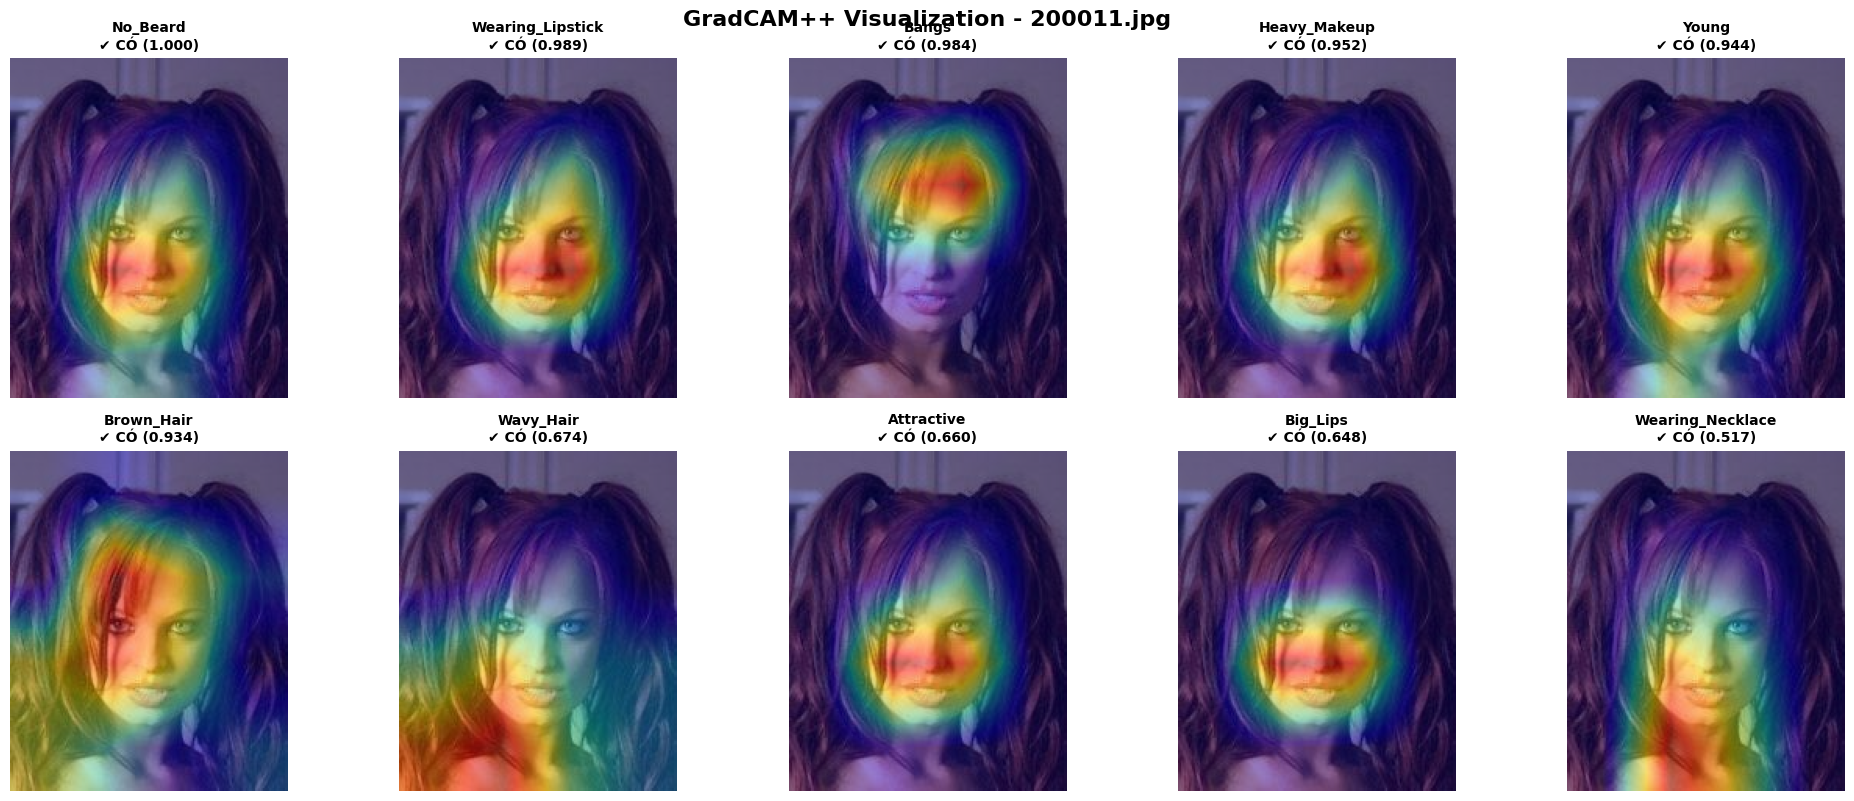


✅ Hiển thị GradCAM++ cho 10 attributes


In [6]:
from torchcam.methods import GradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
import warnings
warnings.filterwarnings('ignore')

def visualize_gradcam_all_attributes(image_file, checkpoint_name="best_model.pth", top_k=10):
    """
    Hiển thị GradCAM++ cho tất cả attributes
    """
    
    # 1. Load Model
    base_model = FaceAttributeModel(num_classes=NUM_CLASSES).to(DEVICE)
    checkpoint_path = os.path.join(PATH_CHECKPOINT, checkpoint_name)
    
    if not os.path.exists(checkpoint_path):
        print(f"Lỗi: Không tìm thấy checkpoint tại {checkpoint_path}")
        return
    
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    state_dict = {k.replace('module.', ''): v for k, v in checkpoint.items()}
    base_model.load_state_dict(state_dict)
    base_model.eval()
    
    # 2. Load Ảnh
    img_path = os.path.join(IMAGE_PATH, image_file)
    if not os.path.exists(img_path):
        print(f"Lỗi: Không tìm thấy ảnh tại {img_path}")
        return
    
    image = Image.open(img_path).convert("RGB")
    input_tensor = inference_transforms(image).unsqueeze(0).to(DEVICE)
    
    # 3. Inference để lấy confidence scores
    with torch.no_grad():
        outputs_initial = base_model(input_tensor)
        confidences = torch.sigmoid(outputs_initial).cpu().squeeze().numpy()
    
    # 4. Chọn top_k attributes
    top_k = min(top_k, NUM_CLASSES)
    top_indices = np.argsort(confidences)[::-1][:top_k]
    
    # 5. Hiển thị
    num_cols = 5
    num_rows = (len(top_indices) + num_cols - 1) // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4*num_rows))
    axes = axes.flatten() if num_rows > 1 else [axes]
    
    original_img = np.array(image) / 255.0
    
    for idx, attr_idx in enumerate(top_indices):
        ax = axes[idx]
        attr_idx = int(attr_idx)
        
        try:
            # Tạo GradCAMpp MỚI cho mỗi attribute (reset hooks)
            cam_extractor = GradCAMpp(base_model, target_layer='features')
            
            # Forward pass VỚI gradient enabled
            input_tensor_grad = input_tensor.clone().requires_grad_(True)
            outputs = base_model(input_tensor_grad)
            
            # Lấy CAM cho class này - TRUYỀN scores vào __call__
            activation_map = cam_extractor(attr_idx, outputs)[0]
            
            # Remove hooks sau khi dùng
            cam_extractor.remove_hooks()
            
            # Chuyển về numpy và xử lý
            if isinstance(activation_map, torch.Tensor):
                activation_map = activation_map.squeeze().cpu().numpy()
            
            # Resize về kích thước ảnh gốc
            activation_map = cv2.resize(activation_map, (image.width, image.height))
            
            # Normalize
            act_min, act_max = activation_map.min(), activation_map.max()
            if act_max - act_min > 1e-8:
                activation_map = (activation_map - act_min) / (act_max - act_min)
            else:
                activation_map = np.zeros_like(activation_map)
            
            # Tạo heatmap với colormap jet
            heatmap = plt.cm.jet(activation_map)[:, :, :3]
            
            # Blend: 60% original + 40% heatmap
            blended = 0.6 * original_img + 0.4 * heatmap
            blended = np.clip(blended, 0, 1)
            
            ax.imshow(blended)
            
            confidence = confidences[attr_idx]
            attr_name = ATTRIBUTE_NAMES[attr_idx]
            pred_label = "✔ CÓ" if confidence > 0.5 else "✗ KHÔNG"
            
            ax.set_title(f"{attr_name}\n{pred_label} ({confidence:.3f})", fontsize=10, fontweight='bold')
            ax.axis('off')
            
        except Exception as e:
            print(f"Warning: {attr_idx} ({ATTRIBUTE_NAMES[attr_idx]}) - {str(e)}")
            ax.imshow(original_img)
            ax.set_title(f"{ATTRIBUTE_NAMES[attr_idx]}\n(Error)", fontsize=10)
            ax.axis('off')
    
    # Hide unused subplots
    for idx in range(len(top_indices), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"GradCAM++ Visualization - {image_file}", fontsize=16, fontweight='bold', y=0.995)
    plt.show()
    
    print(f"\n✅ Hiển thị GradCAM++ cho {len(top_indices)} attributes")

# --- RUN ---
SAMPLE_IMAGE = df_labels['image_id'].iloc[200010]
visualize_gradcam_all_attributes(SAMPLE_IMAGE, checkpoint_name="best_model.pth", top_k=10)